### Métodos usados

In [29]:
def truncar(numero, decimales):
    """
    Trunca un número a un número específico de decimales.
    
    :param numero: El número a truncar
    :param decimales: Cuántos decimales mantener
    :return: Número truncado
    Ejemplo: original=0.335 → truncado=0.33 (2 decimales)
    """
    factor = 10 ** decimales
    return int(numero * factor) / factor


#función eplines cúbicos
def spline_cubico_natural(x, y, decimales = None):
    """
    Calcula los coeficientes del spline cúbico natural para puntos (x_i, y_i).
    
    :param x: lista de valores x (n+1 puntos)
    :param y: lista de valores y correspondientes
    :return: listas a, b, c, d para cada tramo j = 0, ..., n-1
    """
    n = len(x) - 1
    h = [x[i+1] - x[i] for i in range(n)]
    
    # Paso 2: calcular alpha
    alpha = [0] * (n+1)
    for i in range(1, n):
        alpha[i] = 3 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])
    
    # Paso 3: inicialización
    l = [1] + [0] * n
    mu = [0] * (n+1)
    z = [0] * (n+1)
    
    # Paso 4: resolver sistema tridiagonal
    for i in range(1, n):
        l[i] = 2 * (x[i+1] - x[i-1]) - h[i-1] * mu[i-1]
        mu[i] = h[i] / l[i]
        z[i] = (alpha[i] - h[i-1] * z[i-1]) / l[i]
    
    # Paso 5: condiciones naturales
    l[n] = 1
    z[n] = 0
    c = [0] * (n+1)
    
    # Paso 6: retro-substitución
    b = [0] * n
    d = [0] * n
    a = [y[j] for j in range(n)]
    
    for j in reversed(range(n)):
        c[j] = z[j] - mu[j] * c[j+1]
        b[j] = (y[j+1] - y[j]) / h[j] - h[j] * (c[j+1] + 2 * c[j]) / 3
        d[j] = (c[j+1] - c[j]) / (3 * h[j])
    
    #Paso 7: truncar decimales
    if decimales is not None:
        a = [truncar(val, decimales) for val in a]
        b = [truncar(val, decimales) for val in b]
        c = [truncar(val, decimales) for val in c[:n]]
        d = [truncar(val, decimales) for val in d]


    return a, b, c[:n], d


In [30]:
def newton(x0,f, df, tol=1e-6, num_iter=10):
    """
    Método de Newton-Raphson para encontrar una raíz de f(x).
    
    Parámetros:
        x0 (float): valor inicial (punto de partida)
        tol (float): tolerancia para el criterio de parada
        num_iter (int): número máximo de iteraciones
    
    Retorna:
        float: aproximación de la raíz
    """

    i=0
    while i<num_iter:
        x1 = x0 - f(x0)/df(x0)
        print ('iteracion: ', i, 'x = ', x0, 'f(x) = ', f(x0), "f'(x)=", df(x0), 'tolerancia', abs(x1 - x0))
        if abs(x1 - x0) < tol:
            print('La raiz es:', truncar(x1,4),'con interaciones', i)
            return truncar(x1,4)
        x0 = truncar(x1,4)
        i += 1
    print('El metodo falló depués de ', num_iter, 'iteraciones')
    return None


## datos filtrados y promediados 


In [31]:
def evaluar_spline(x_eval, x, a, b, c, d):
    """
    Evalúa el spline cúbico en los puntos x_eval
    """
    y_eval = []

    for xv in x_eval:
        # buscar el tramo correcto
        for j in range(len(a)):
            if x[j] <= xv <= x[j+1]:
                dx = xv - x[j]
                yv = a[j] + b[j]*dx + c[j]*dx**2 + d[j]*dx**3
                y_eval.append(yv)
                break

    return y_eval


### etapa 3 identififcar picos y valles

In [32]:
#importer, limpiar y ordenar datasets 
import pandas as pd


#importear dataset 
ds = pd.read_csv('../Dataset/household_energy_consumption.csv')
ds =  ds[['Avg_Temperature_C', 'Energy_Consumption_kWh', 'Has_AC']]

#filtrar datos por uso de aire acondicionado y sin uso de aire acondicionado
ds_aire = ds[ds['Has_AC'] == 'Yes']
ds_no_aire = ds[ds['Has_AC'] == 'No']

#=Eliminar columna Has_AC y filas 
ds_aire = ds_aire[['Avg_Temperature_C', 'Energy_Consumption_kWh' ]]
ds_no_aire = ds_no_aire[['Avg_Temperature_C', 'Energy_Consumption_kWh' ]]

#limpiar datos nulos
ds_aire=ds_aire.dropna()
ds_no_aire=ds_no_aire.dropna()

#Eliminar datos repetidos
ds_no_aire = ds_no_aire.groupby(['Avg_Temperature_C']).mean().reset_index()
ds_aire = ds_aire.groupby(['Avg_Temperature_C']).mean().reset_index()

#ordenar datos por temperatura
ds_aire = ds_aire.sort_values(by='Avg_Temperature_C')
ds_no_aire = ds_no_aire.sort_values(by='Avg_Temperature_C')

#guardar datos limpios
ds_aire.to_csv('../Dataset/datos_aire.csv', index=False)
ds_no_aire.to_csv('../Dataset/datos_no_aire.csv', index=False)


#mostrar primeras filas de los datasets limpios
print(ds_aire.head())
print(ds_no_aire.head())





   Avg_Temperature_C  Energy_Consumption_kWh
0               10.0               12.047619
1               10.1               13.800000
2               10.2               10.181818
3               10.3               10.712500
4               10.4               14.190000
   Avg_Temperature_C  Energy_Consumption_kWh
0               10.0                8.074648
1               10.1                8.185714
2               10.2                8.293750
3               10.3                7.008333
4               10.4                9.758333


In [33]:
x_aire =  ds_aire['Avg_Temperature_C'].tolist()
y_aire =  ds_aire['Energy_Consumption_kWh'].tolist()


x_no_aire =  ds_no_aire['Avg_Temperature_C'].tolist()
y_no_aire =  ds_no_aire['Energy_Consumption_kWh'].tolist()



In [34]:
a, b, c, d, = spline_cubico_natural(x_aire, y_aire, decimales = 4)
a1, b1, c1, d1 = spline_cubico_natural(x_no_aire, y_no_aire, decimales = 4)


def evaluar_spline(x_eval, x, a, b, c, d):
      
    for j in range(len(a)):
            if x[j] <= x_eval <= x[j+1]:
                dx = x_eval - x[j]
                return a[j] + b[j]*dx + c[j]*dx**2 + d[j]*dx**3
    return None

#y_no_aire = [evaluar_spline(xv, x_no_aire, a1, b1, c1, d1) for xv in x_no_aire]
#y_aire = [evaluar_spline(xv, x_aire, a, b, c, d) for xv in x_aire]

Text(0.5, 1.0, 'Consumo de energia con aire acondicionado')

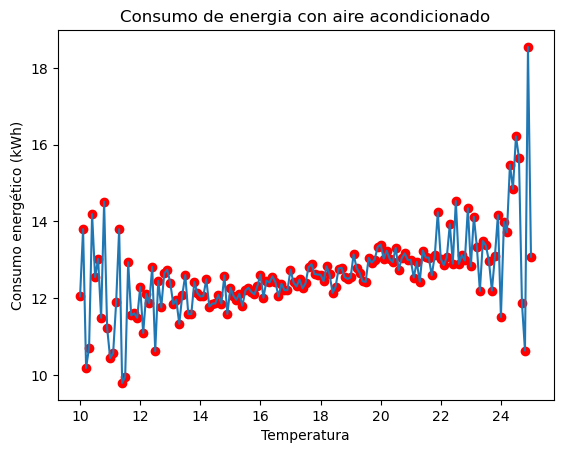

In [35]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(x_aire, y_aire, color='red')
plt.plot(x_aire, y_aire)
plt.xlabel("Temperatura")
plt.ylabel("Consumo energético (kWh)")
plt.title("Consumo de energia con aire acondicionado")

Text(0.5, 1.0, 'Consumo de energia sin aire acondicionado')

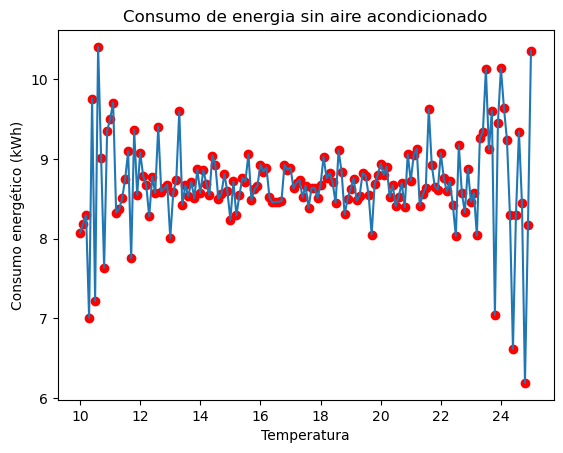

In [36]:
plt.figure()
plt.scatter(x_no_aire, y_no_aire, color='red')

plt.plot(x_no_aire, y_no_aire)
plt.xlabel("Temperatura")
plt.ylabel("Consumo energético (kWh)")
plt.title("Consumo de energia sin aire acondicionado")

Text(0.5, 1.0, 'Consumo de energia con aire acondicionado')

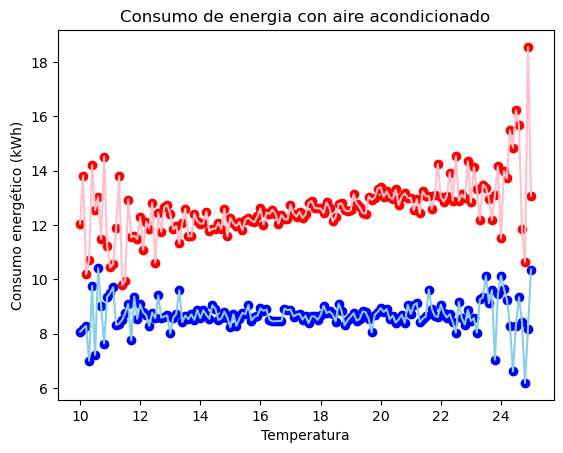

In [16]:
plt.figure()
plt.scatter(x_aire, y_aire, color='red')
plt.scatter(x_no_aire, y_no_aire, color='blue')
plt.plot(x_aire, y_aire, color='pink')
plt.plot(x_no_aire, y_no_aire, color='skyblue')
plt.xlabel("Temperatura")
plt.ylabel("Consumo energético (kWh)")
plt.title("Consumo de energia con aire acondicionado")